In [3]:
!pip install xgboost scikit-learn joblib scipy seaborn matplotlib pandas numpy -q

In [4]:
from google.colab import files

print("Upload your dataset files:")
print("  - ai4i_2020_predictive_maintenance_dataset.zip")
print("  - aps_failure_at_scania_trucks.zip")
print("  (Upload both, or just one)")

uploaded = files.upload()
print("\nUploaded:", list(uploaded.keys()))

Upload your dataset files:
  - ai4i_2020_predictive_maintenance_dataset.zip
  - aps_failure_at_scania_trucks.zip
  (Upload both, or just one)


Saving VED-master.zip to VED-master.zip
Saving aps+failure+at+scania+trucks.zip to aps+failure+at+scania+trucks.zip
Saving 1.+Algae+Raceway.zip to 1.+Algae+Raceway.zip
Saving ai4i+2020+predictive+maintenance+dataset.zip to ai4i+2020+predictive+maintenance+dataset.zip

Uploaded: ['VED-master.zip', 'aps+failure+at+scania+trucks.zip', '1.+Algae+Raceway.zip', 'ai4i+2020+predictive+maintenance+dataset.zip']


In [10]:
import os

dirs = [
    "/content/vehicle_health_engine/src",
    "/content/vehicle_health_engine/data",
    "/content/vehicle_health_engine/models",
    "/content/vehicle_health_engine/outputs",
]
for d in dirs:
    os.makedirs(d, exist_ok=True)

# Move uploaded files to data/
import shutil
for fname, content in uploaded.items():
    # Write the content to a temporary file in the current directory
    with open(fname, "wb") as f:
        f.write(content)
    # Now move the file from the current directory to the target data directory
    shutil.move(fname, f"/content/vehicle_health_engine/data/{fname}")
    print(f"Moved {fname} → data/")

print("\nProject structure ready.")

Moved VED-master.zip → data/
Moved aps+failure+at+scania+trucks.zip → data/
Moved 1.+Algae+Raceway.zip → data/
Moved ai4i+2020+predictive+maintenance+dataset.zip → data/

Project structure ready.


In [11]:
%%writefile /content/vehicle_health_engine/src/config.py
from pathlib import Path

ROOT_DIR   = Path("/content/vehicle_health_engine")
DATA_DIR   = ROOT_DIR / "data"
MODELS_DIR = ROOT_DIR / "models"
OUTPUT_DIR = ROOT_DIR / "outputs"

SCHEMA_COLUMNS = ["timestamp","temperature","pressure","rpm","vibration",
                  "battery_voltage","battery_current","battery_temp","fault_count","failure"]
SENSOR_COLUMNS = ["temperature","pressure","rpm","vibration",
                  "battery_voltage","battery_current","battery_temp","fault_count"]

SCALER_TYPE = "minmax"
OUTLIER_METHOD = "iqr"
OUTLIER_IQR_MULTIPLIER = 1.5
OUTLIER_ZSCORE_THRESHOLD = 3.0
ROLLING_WINDOW = 5

ENGINE_THRESHOLDS = {
    "temperature": {"optimal_max": 90.0, "warning": 100.0, "critical": 110.0},
    "pressure":    {"optimal_min": 25.0, "warning": 20.0,  "critical": 15.0},
    "rpm":         {"optimal_max": 4000.0,"warning": 5000.0,"critical": 6500.0},
    "vibration":   {"optimal_max": 0.3,  "warning": 0.6,   "critical": 1.0},
    "fault_count": {"warning": 3, "critical": 7},
}
ENGINE_PENALTY_WEIGHTS = {"temperature":20,"pressure":20,"rpm":20,"vibration":20,"fault_count":20}

BATTERY_THRESHOLDS = {
    "voltage": {"nominal": 12.6, "warning": 11.8, "critical": 11.0},
    "current": {"max_draw": 100.0, "warning": 80.0, "critical": 120.0},
    "temp":    {"optimal_max": 45.0, "warning": 55.0, "critical": 65.0},
}

VEHICLE_HEALTH_WEIGHTS = {"engine": 0.7, "battery": 0.3}

HEALTH_CLASS_MAP = [
    (90, "Excellent", 0),
    (75, "Good",      1),
    (60, "Warning",   2),
    (0,  "Critical",  3),
]

TRIP_READINESS_WEIGHTS = {"vehicle_health": 0.6, "battery_health": 0.2,
                           "fault_penalty": 0.2, "fault_multiplier": 10}
TRIP_READINESS_LABELS = [(70, "Ready"), (50, "Caution"), (0, "Not Recommended")]

TEST_SIZE   = 0.2
RANDOM_SEED = 42
CV_FOLDS    = 5

XGBOOST_CLASSIFIER_PARAMS = {
    "n_estimators": 200, "max_depth": 6, "learning_rate": 0.05,
    "subsample": 0.8, "colsample_bytree": 0.8,
    "eval_metric": "logloss", "random_state": RANDOM_SEED,
}
XGBOOST_REGRESSOR_PARAMS = {
    "n_estimators": 200, "max_depth": 6, "learning_rate": 0.05,
    "subsample": 0.8, "colsample_bytree": 0.8, "random_state": RANDOM_SEED,
}

OUTPUT_DATASET_PATH   = OUTPUT_DIR / "vehicle_health_dataset.csv"
CLASSIFIER_MODEL_PATH = MODELS_DIR / "failure_classifier.joblib"
REGRESSOR_MODEL_PATH  = MODELS_DIR / "rul_regressor.joblib"
SCALER_PATH           = MODELS_DIR / "feature_scaler.joblib"

Overwriting /content/vehicle_health_engine/src/config.py


In [12]:
%%writefile /content/vehicle_health_engine/src/utils.py
import logging, sys
from pathlib import Path
from typing import Optional
import numpy as np
import pandas as pd

def get_logger(name, log_file=None, level=logging.INFO):
    logger = logging.getLogger(name)
    if logger.handlers:
        return logger
    logger.setLevel(level)
    fmt = logging.Formatter("%(asctime)s | %(levelname)-8s | %(name)s | %(message)s",
                            datefmt="%H:%M:%S")
    ch = logging.StreamHandler(sys.stdout)
    ch.setFormatter(fmt)
    logger.addHandler(ch)
    if log_file:
        Path(log_file).parent.mkdir(parents=True, exist_ok=True)
        fh = logging.FileHandler(log_file)
        fh.setFormatter(fmt)
        logger.addHandler(fh)
    return logger

def log_dataset_stats(df, logger, label="dataset"):
    logger.info(f"[{label}] shape: {df.shape}")
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if not missing.empty:
        logger.warning(f"[{label}] missing:\n{missing.to_string()}")

def detect_numeric_columns(df):
    return df.select_dtypes(include=[np.number]).columns.tolist()

def clamp(value, lo=0.0, hi=100.0):
    return max(lo, min(hi, value))

def remap_columns(df, mapping):
    available = {k: v for k, v in mapping.items() if k in df.columns}
    return df.rename(columns=available)

def generate_synthetic_dataset(n_rows=2000, seed=42):
    rng = np.random.default_rng(seed)
    timestamps = pd.date_range(start="2024-01-01", periods=n_rows, freq="1min")
    temperature     = rng.normal(85, 15, n_rows).clip(40, 140)
    pressure        = rng.normal(30, 6, n_rows).clip(5, 60)
    rpm             = rng.normal(2500, 800, n_rows).clip(500, 7000)
    vibration       = rng.exponential(0.25, n_rows).clip(0, 2)
    battery_voltage = rng.normal(12.4, 0.4, n_rows).clip(10, 15)
    battery_current = rng.normal(50, 20, n_rows).clip(0, 150)
    battery_temp    = rng.normal(35, 10, n_rows).clip(10, 80)
    fault_count     = rng.integers(0, 10, n_rows)
    failure_prob = (0.3*(temperature>105).astype(float) +
                   0.3*(fault_count>6).astype(float) +
                   0.1*rng.random(n_rows))
    failure = (failure_prob > 0.4).astype(int)
    return pd.DataFrame({
        "timestamp": timestamps, "temperature": temperature,
        "pressure": pressure, "rpm": rpm, "vibration": vibration,
        "battery_voltage": battery_voltage, "battery_current": battery_current,
        "battery_temp": battery_temp, "fault_count": fault_count.astype(float),
        "failure": failure,
    })

Writing /content/vehicle_health_engine/src/utils.py


In [13]:
%%writefile /content/vehicle_health_engine/src/datasets.py
from __future__ import annotations
import io, zipfile
from pathlib import Path
from typing import Optional, Union
import numpy as np
import pandas as pd
import sys
sys.path.insert(0, "/content/vehicle_health_engine")
from src.utils import get_logger

logger = get_logger(__name__)

SCHEMA_COLS = ["timestamp","temperature","pressure","rpm","vibration",
               "battery_voltage","battery_current","battery_temp","fault_count","failure"]

def _ensure_schema(df, source_name):
    for col in SCHEMA_COLS:
        if col not in df.columns:
            df[col] = 0 if col == "failure" else np.nan
    df["failure"]     = df["failure"].fillna(0).astype(int)
    df["fault_count"] = df["fault_count"].fillna(0).astype(float)
    if "timestamp" in df.columns:
        df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
    return df[SCHEMA_COLS + [c for c in df.columns if c not in SCHEMA_COLS]]

def _normalise_0_1(series):
    lo, hi = series.min(), series.max()
    if hi == lo: return pd.Series(0.0, index=series.index)
    return (series - lo) / (hi - lo)

def load_ai4i(path):
    path = Path(path)
    logger.info("[AI4I] Loading from: %s", path)
    if path.suffix == ".zip":
        with zipfile.ZipFile(path) as zf:
            csv_name = [n for n in zf.namelist() if n.endswith(".csv")][0]
            with zf.open(csv_name) as f:
                df = pd.read_csv(f)
    else:
        df = pd.read_csv(path)
    logger.info("[AI4I] Raw shape: %s", df.shape)

    rename = {"Air temperature [K]": "_air_k", "Process temperature [K]": "_proc_k",
              "Rotational speed [rpm]": "rpm", "Torque [Nm]": "_torque",
              "Tool wear [min]": "fault_count", "Machine failure": "failure"}
    df = df.rename(columns={k:v for k,v in rename.items() if k in df.columns})

    df["temperature"] = df["_air_k"] - 273.15 if "_air_k" in df.columns else np.nan
    if "_proc_k" in df.columns and "_air_k" in df.columns:
        delta_norm = _normalise_0_1(df["_proc_k"] - df["_air_k"])
        df["pressure"] = 45.0 - 30.0 * delta_norm
    else:
        df["pressure"] = np.nan
    df["vibration"] = _normalise_0_1(df["_torque"]) if "_torque" in df.columns else np.nan
    if "fault_count" in df.columns:
        df["fault_count"] = (15.0 * _normalise_0_1(df["fault_count"].fillna(0))).round(0)
    df["timestamp"] = pd.NaT
    df = df.drop(columns=["_air_k","_proc_k","_torque"], errors="ignore")
    df = _ensure_schema(df, "AI4I")
    df["_source"] = "ai4i"
    logger.info("[AI4I] Adapted shape: %s | failure rate: %.2f%%", df.shape, 100*df["failure"].mean())
    return df

def load_scania(path, split="train"):
    path = Path(path)
    logger.info("[Scania] Loading split='%s' from: %s", split, path)
    if path.is_file() and path.suffix == ".zip":
        fname = f"aps_failure_{split}ing_set.csv"
        with zipfile.ZipFile(path) as zf:
            names = [n for n in zf.namelist() if fname in n]
            if not names:
                raise FileNotFoundError(f"'{fname}' not found in zip")
            with zf.open(names[0]) as f:
                raw = f.read()
        df = pd.read_csv(io.BytesIO(raw), skiprows=20, na_values=["na","NA","Na",""])
    else:
        df = pd.read_csv(path, skiprows=20, na_values=["na","NA","Na",""])
    logger.info("[Scania] Raw shape: %s", df.shape)

    if "class" in df.columns:
        failure_vals = (df["class"].str.strip().str.lower() == "pos").astype(int).values
        df = df.drop(columns=["class"]).copy()
        df["failure"] = failure_vals
    else:
        df["failure"] = 0

    schema_map = {"aa_000":"temperature","ab_000":"pressure",
                  "ac_000":"rpm","ad_000":"vibration","ba_000":"fault_count"}
    df = df.rename(columns={k:v for k,v in schema_map.items() if k in df.columns})

    for col, lo, hi in [("temperature",40,120),("pressure",15,45),("rpm",500,6500)]:
        if col in df.columns:
            df[col] = lo + (hi-lo)*_normalise_0_1(df[col].fillna(df[col].median()))
    if "vibration" in df.columns:
        df["vibration"] = _normalise_0_1(df["vibration"].fillna(df["vibration"].median()))
    if "fault_count" in df.columns:
        df["fault_count"] = (15.0*_normalise_0_1(df["fault_count"].fillna(0))).round(0)

    # Keep a few extra sensor groups as ML features
    extra_rename = {}
    for grp in ["ae","af","ag","bk","bl","bm","ee"]:
        for col in [c for c in df.columns if c.startswith(f"{grp}_")][:3]:
            extra_rename[col] = f"scania_{col}"
    df = df.rename(columns=extra_rename)
    keep = set(SCHEMA_COLS) | set(extra_rename.values()) | {"failure"}
    df = df.drop(columns=[c for c in df.columns if c not in keep], errors="ignore").copy()

    df["timestamp"] = pd.NaT
    df = _ensure_schema(df, "Scania")
    df["_source"] = "scania"
    logger.info("[Scania] Adapted shape: %s | failure rate: %.2f%%", df.shape, 100*df["failure"].mean())
    return df

def merge_datasets(dfs, reset_index=True):
    non_empty = [d for d in dfs if not d.empty]
    if not non_empty:
        raise ValueError("All DataFrames are empty.")
    merged = pd.concat(non_empty, ignore_index=True, sort=False)
    merged = merged.sample(frac=1.0, random_state=42)
    if reset_index:
        merged = merged.reset_index(drop=True)
    logger.info("[Merge] shape: %s | failure rate: %.2f%%", merged.shape, 100*merged["failure"].mean())
    return merged

Writing /content/vehicle_health_engine/src/datasets.py


In [15]:
%%writefile /content/vehicle_health_engine/src/preprocess.py
from pathlib import Path
from typing import Optional
import joblib, numpy as np, pandas as pd
from scipy import stats
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import sys
sys.path.insert(0, "/content/vehicle_health_engine")
from src.config import *
from src.utils import detect_numeric_columns, get_logger, log_dataset_stats, remap_columns

logger = get_logger(__name__)

def load_and_clean(path=None, df_raw=None, column_mapping=None):
    if df_raw is not None:
        df = df_raw.copy()
    elif path is not None:
        df = pd.read_csv(Path(path))
    else:
        raise ValueError("Provide path or df_raw.")
    if column_mapping:
        df = remap_columns(df, column_mapping)
    if "timestamp" in df.columns:
        df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
    for col in SENSOR_COLUMNS:
        if col not in df.columns:
            df[col] = np.nan
    if "failure" not in df.columns:
        df["failure"] = 0
    num_cols = detect_numeric_columns(df)
    df[num_cols] = df[num_cols].fillna(df[num_cols].median())
    df = df.drop_duplicates().reset_index(drop=True)
    sensor_num = [c for c in SENSOR_COLUMNS if c in num_cols]
    for col in sensor_num:
        q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        iqr = q3 - q1
        df[col] = df[col].clip(q1 - 1.5*iqr, q3 + 1.5*iqr)
    logger.info("Cleaned shape: %s", df.shape)
    return df

def scale_features(df, fit=True, scaler=None, columns=None):
    df = df.copy()
    if columns is None:
        columns = [c for c in SENSOR_COLUMNS if c in df.columns]
    if fit:
        scaler = MinMaxScaler() if SCALER_TYPE == "minmax" else StandardScaler()
        df[columns] = scaler.fit_transform(df[columns])
    else:
        df[columns] = scaler.transform(df[columns])
    return df, scaler

def save_scaler(scaler, path=None):
    p = Path(path) if path else SCALER_PATH
    p.parent.mkdir(parents=True, exist_ok=True)
    joblib.dump(scaler, p)

def load_scaler(path=None):
    p = Path(path) if path else SCALER_PATH
    return joblib.load(p)

Overwriting /content/vehicle_health_engine/src/preprocess.py


In [16]:
%%writefile /content/vehicle_health_engine/src/feature_engineering.py
from typing import Optional
import numpy as np, pandas as pd
import sys
sys.path.insert(0, "/content/vehicle_health_engine")
from src.config import ROLLING_WINDOW
from src.utils import get_logger

logger = get_logger(__name__)
ENGINEERED_COLUMNS = ["temp_pressure_ratio","rpm_per_temperature","vibration_risk",
                      "thermal_stress","fault_density","rolling_mean_temp",
                      "rolling_mean_rpm","rolling_std_vibration"]

def engineer_features(df, window=None):
    df = df.copy()
    window = window or ROLLING_WINDOW
    with np.errstate(divide="ignore", invalid="ignore"):
        df["temp_pressure_ratio"] = np.where(df["pressure"]!=0, df["temperature"]/df["pressure"], np.nan)
        df["rpm_per_temperature"] = np.where(df["temperature"]!=0, df["rpm"]/df["temperature"], np.nan)
    vib_max = df["vibration"].max() or 1.0
    df["vibration_risk"] = (df["vibration"]/vib_max).clip(0,1)
    temp_max = df["temperature"].max() or 1.0
    batt_max = df["battery_temp"].max() or 1.0
    df["thermal_stress"] = (0.6*df["temperature"]/temp_max + 0.4*df["battery_temp"]/batt_max).clip(0,1)
    fault_ref = max(df["fault_count"].max(), 10.0)
    df["fault_density"] = (df["fault_count"]/fault_ref).clip(0,1)
    df["rolling_mean_temp"]      = df["temperature"].rolling(window, min_periods=1).mean()
    df["rolling_mean_rpm"]       = df["rpm"].rolling(window, min_periods=1).mean()
    df["rolling_std_vibration"]  = df["vibration"].rolling(window, min_periods=1).std().fillna(0)
    for col in ENGINEERED_COLUMNS:
        if df[col].isnull().any():
            df[col] = df[col].fillna(df[col].median())
    logger.info("Feature engineering complete.")
    return df

Writing /content/vehicle_health_engine/src/feature_engineering.py


In [17]:
%%writefile /content/vehicle_health_engine/src/health_scoring.py
import numpy as np, pandas as pd
import sys
sys.path.insert(0, "/content/vehicle_health_engine")
from src.config import *
from src.utils import get_logger

logger = get_logger(__name__)

def compute_engine_health(df):
    score = pd.Series(100.0, index=df.index)
    t,p,r,v,fc = df["temperature"],df["pressure"],df["rpm"],df["vibration"],df["fault_count"]
    et,pw = ENGINE_THRESHOLDS, ENGINE_PENALTY_WEIGHTS
    for col, val, direction in [
        ("temperature", t, "high"), ("pressure", p, "low"),
        ("rpm", r, "high"), ("vibration", v, "high")]:
        if direction == "high":
            opt = et[col]["optimal_max"]; warn = et[col]["warning"]; crit = et[col]["critical"]
            pen = np.where(val<=opt, 0,
                  np.where(val<=warn, pw[col]*(val-opt)/(warn-opt),
                  np.where(val<=crit, pw[col], pw[col]*1.5)))
        else:
            opt = et[col]["optimal_min"]; warn = et[col]["warning"]; crit = et[col]["critical"]
            pen = np.where(val>=opt, 0,
                  np.where(val>=warn, pw[col]*(opt-val)/(opt-warn),
                  np.where(val>=crit, pw[col], pw[col]*1.5)))
        score -= pen
    fc_warn,fc_crit = et["fault_count"]["warning"],et["fault_count"]["critical"]
    score -= np.where(fc<=fc_warn, 0,
             np.where(fc<=fc_crit, pw["fault_count"]*(fc-fc_warn)/(fc_crit-fc_warn), pw["fault_count"]))
    return score.clip(0,100).rename("engine_health")

def compute_battery_health(df):
    score = pd.Series(100.0, index=df.index)
    bt = BATTERY_THRESHOLDS
    v,c,bt_temp = df["battery_voltage"],df["battery_current"],df["battery_temp"]
    v_nom,v_warn,v_crit = bt["voltage"]["nominal"],bt["voltage"]["warning"],bt["voltage"]["critical"]
    score -= np.where(v>=v_nom, 0, np.where(v>=v_warn, 33*(v_nom-v)/(v_nom-v_warn),
             np.where(v>=v_crit, 33, 50)))
    c_max,c_warn,c_crit = bt["current"]["max_draw"],bt["current"]["warning"],bt["current"]["critical"]
    score -= np.where(c<=c_warn, 0, np.where(c<=c_max, 33*(c-c_warn)/(c_max-c_warn),
             np.where(c<=c_crit, 33, 50)))
    bt_opt,bt_warn,bt_crit = bt["temp"]["optimal_max"],bt["temp"]["warning"],bt["temp"]["critical"]
    score -= np.where(bt_temp<=bt_opt, 0, np.where(bt_temp<=bt_warn, 34*(bt_temp-bt_opt)/(bt_warn-bt_opt),
             np.where(bt_temp<=bt_crit, 34, 50)))
    return score.clip(0,100).rename("battery_health")

def compute_vehicle_health(engine_health, battery_health):
    w = VEHICLE_HEALTH_WEIGHTS
    return (w["engine"]*engine_health + w["battery"]*battery_health).clip(0,100).rename("vehicle_health")

def assign_health_class(vehicle_health):
    def _c(s):
        for lb,lbl,cid in HEALTH_CLASS_MAP:
            if s >= lb: return lbl,cid
        return "Critical",3
    res = vehicle_health.apply(_c)
    return pd.DataFrame(res.tolist(), columns=["health_class","health_class_id"], index=vehicle_health.index)

def compute_trip_readiness(df):
    w = TRIP_READINESS_WEIGHTS
    fault_term = (100 - df["fault_count"]*w["fault_multiplier"]).clip(0,100)
    score = (w["vehicle_health"]*df["vehicle_health"] +
             w["battery_health"]*df["battery_health"] +
             w["fault_penalty"]*fault_term).clip(0,100)
    def _lbl(s):
        for t,l in TRIP_READINESS_LABELS:
            if s >= t: return l
        return "Not Recommended"
    return pd.DataFrame({"trip_readiness":score,"trip_readiness_label":score.apply(_lbl)}, index=df.index)

def add_all_health_scores(df):
    df = df.copy()
    df["engine_health"]  = compute_engine_health(df)
    df["battery_health"] = compute_battery_health(df)
    df["vehicle_health"] = compute_vehicle_health(df["engine_health"], df["battery_health"])
    df = pd.concat([df, assign_health_class(df["vehicle_health"])], axis=1)
    df = pd.concat([df, compute_trip_readiness(df)], axis=1)
    return df

Writing /content/vehicle_health_engine/src/health_scoring.py


In [18]:
%%writefile /content/vehicle_health_engine/src/train_classifier.py
from pathlib import Path
from typing import Optional
import joblib, numpy as np, pandas as pd
import matplotlib; matplotlib.use("Agg")
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix,
    f1_score, precision_score, recall_score, roc_auc_score)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from xgboost import XGBClassifier
import sys
sys.path.insert(0, "/content/vehicle_health_engine")
from src.config import *
from src.utils import get_logger

logger = get_logger(__name__)
_EXCLUDE = {"timestamp","failure","health_class","health_class_id","trip_readiness_label","ml_health_score"}

def get_feature_columns(df):
    return [c for c in df.select_dtypes(include=[np.number]).columns if c not in _EXCLUDE]

def train_failure_classifier(df):
    feature_cols = get_feature_columns(df)
    X = df[feature_cols].values
    y = df["failure"].values.astype(int)
    logger.info("Class dist — 0: %d  1: %d  (%.1f%% pos)", (y==0).sum(), (y==1).sum(), 100*y.mean())
    X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=TEST_SIZE,
                                                      random_state=RANDOM_SEED, stratify=y)
    model = XGBClassifier(**XGBOOST_CLASSIFIER_PARAMS)
    cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_SEED)
    cv_scores = cross_val_score(model,X_train,y_train,cv=cv,scoring="roc_auc",n_jobs=-1)
    logger.info("CV ROC-AUC: %.4f ± %.4f", cv_scores.mean(), cv_scores.std())
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1]
    precision = precision_score(y_test,y_pred,zero_division=0)
    recall    = recall_score(y_test,y_pred,zero_division=0)
    f1        = f1_score(y_test,y_pred,zero_division=0)
    roc_auc   = roc_auc_score(y_test,y_proba)
    logger.info("Precision: %.4f  Recall: %.4f  F1: %.4f  ROC-AUC: %.4f", precision,recall,f1,roc_auc)
    # Save confusion matrix
    try:
        OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
        cm = confusion_matrix(y_test,y_pred)
        fig,ax = plt.subplots(figsize=(5,4))
        sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",
                    xticklabels=["No Failure","Failure"],yticklabels=["No Failure","Failure"],ax=ax)
        ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
        ax.set_title("Failure Classifier — Confusion Matrix")
        fig.tight_layout(); fig.savefig(OUTPUT_DIR/"confusion_matrix.png",dpi=120); plt.close(fig)
    except Exception as e:
        logger.warning("Could not save confusion matrix: %s", e)
    return model, {"precision":precision,"recall":recall,"f1":f1,"roc_auc":roc_auc,
                   "cv_roc_auc_mean":float(cv_scores.mean()),"feature_columns":feature_cols}

def add_ml_health_score(df, model):
    df = df.copy()
    X = df[get_feature_columns(df)].values
    df["ml_health_score"] = (100*(1 - model.predict_proba(X)[:,1])).clip(0,100)
    return df

def save_classifier(model, path=None):
    p = Path(path) if path else CLASSIFIER_MODEL_PATH
    p.parent.mkdir(parents=True, exist_ok=True)
    joblib.dump(model, p)
    logger.info("Classifier saved → %s", p)

def load_classifier(path=None):
    p = Path(path) if path else CLASSIFIER_MODEL_PATH
    return joblib.load(p)

Writing /content/vehicle_health_engine/src/train_classifier.py


In [19]:
%%writefile /content/vehicle_health_engine/src/train_regressor.py
from pathlib import Path
from typing import Optional
import joblib, numpy as np, pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
import sys
sys.path.insert(0, "/content/vehicle_health_engine")
from src.config import *
from src.train_classifier import _EXCLUDE
from src.utils import get_logger

logger = get_logger(__name__)
_RUL_EXCLUDE = _EXCLUDE | {"RUL","RUL_synthetic"}

def prepare_rul_target(df):
    df = df.copy()
    if "RUL" in df.columns:
        df["RUL_synthetic"] = False
        return df
    logger.warning("⚠ No RUL column — generating SYNTHETIC RUL from vehicle_health.")
    rng = np.random.default_rng(RANDOM_SEED)
    df["RUL"]           = (df["vehicle_health"]*2.0 + rng.normal(0,5,len(df))).clip(0,200)
    df["RUL_synthetic"] = True
    return df

def train_rul_regressor(df):
    feature_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c not in _RUL_EXCLUDE]
    X = df[feature_cols].values
    y = df["RUL"].values.astype(float)
    X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=TEST_SIZE,random_state=RANDOM_SEED)
    model = XGBRegressor(**XGBOOST_REGRESSOR_PARAMS)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    logger.info("RUL — MAE: %.4f  RMSE: %.4f  R²: %.4f", mae, rmse, r2)
    return model, {"mae":mae,"rmse":rmse,"r2":r2,
                   "synthetic_rul":bool(df.get("RUL_synthetic",pd.Series([False])).any())}

def save_regressor(model, path=None):
    p = Path(path) if path else REGRESSOR_MODEL_PATH
    p.parent.mkdir(parents=True, exist_ok=True)
    joblib.dump(model, p)

def load_regressor(path=None):
    p = Path(path) if path else REGRESSOR_MODEL_PATH
    return joblib.load(p)

Writing /content/vehicle_health_engine/src/train_regressor.py


In [20]:
%%writefile /content/vehicle_health_engine/src/__init__.py
# vehicle_health_engine/src

Writing /content/vehicle_health_engine/src/__init__.py


In [21]:
import sys, time
sys.path.insert(0, "/content/vehicle_health_engine")

from src.config import *
from src.datasets import load_ai4i, load_scania, merge_datasets
from src.preprocess import load_and_clean, scale_features, save_scaler
from src.feature_engineering import engineer_features
from src.health_scoring import add_all_health_scores
from src.train_classifier import train_failure_classifier, add_ml_health_score, save_classifier
from src.train_regressor import prepare_rul_target, train_rul_regressor, save_regressor
from src.utils import get_logger, generate_synthetic_dataset

logger = get_logger("pipeline")

# ── Detect which datasets were uploaded ──────────────────────────────────────
DATA = Path("/content/vehicle_health_engine/data")
frames = []

ai4i_zip   = DATA / "ai4i_2020_predictive_maintenance_dataset.zip"
scania_zip  = DATA / "aps_failure_at_scania_trucks.zip"

if ai4i_zip.exists():
    logger.info("Loading AI4I …")
    frames.append(load_ai4i(ai4i_zip))

if scania_zip.exists():
    logger.info("Loading Scania …")
    frames.append(load_scania(scania_zip, split="train"))

if not frames:
    logger.warning("No datasets found — using synthetic data.")
    raw = generate_synthetic_dataset()
    raw["_source"] = "synthetic"
    frames.append(raw)

# ── Merge ─────────────────────────────────────────────────────────────────────
corpus = merge_datasets(frames) if len(frames) > 1 else frames[0].reset_index(drop=True)
logger.info("Corpus shape: %s", corpus.shape)

# ── Preprocess ────────────────────────────────────────────────────────────────
df_raw    = load_and_clean(df_raw=corpus)
df_scaled, scaler = scale_features(df_raw, fit=True)
save_scaler(scaler)

# ── Feature engineering ───────────────────────────────────────────────────────
df_raw    = engineer_features(df_raw)
df_scaled = engineer_features(df_scaled)

# ── Health scores ─────────────────────────────────────────────────────────────
df_raw = add_all_health_scores(df_raw)
for col in ["engine_health","battery_health","vehicle_health","health_class",
            "health_class_id","trip_readiness","trip_readiness_label","failure"]:
    if col in df_raw.columns:
        df_scaled[col] = df_raw[col].values

# ── Train classifier ──────────────────────────────────────────────────────────
logger.info("Training failure classifier …")
clf, clf_metrics = train_failure_classifier(df_scaled)
save_classifier(clf)
logger.info("Classifier metrics: precision=%.3f recall=%.3f f1=%.3f roc_auc=%.3f",
            clf_metrics["precision"], clf_metrics["recall"],
            clf_metrics["f1"], clf_metrics["roc_auc"])

# ── ML health score ───────────────────────────────────────────────────────────
df_raw    = add_ml_health_score(df_raw, clf)
df_scaled["ml_health_score"] = df_raw["ml_health_score"].values

# ── Train RUL regressor ───────────────────────────────────────────────────────
logger.info("Training RUL regressor …")
df_rul = prepare_rul_target(df_scaled)
rul, rul_metrics = train_rul_regressor(df_rul)
save_regressor(rul)
logger.info("RUL metrics: mae=%.3f rmse=%.3f r2=%.3f", rul_metrics["mae"],
            rul_metrics["rmse"], rul_metrics["r2"])

# ── Save enriched dataset ─────────────────────────────────────────────────────
FINAL_COLS = ["temperature","pressure","rpm","vibration",
              "battery_voltage","battery_current","battery_temp","fault_count",
              "engine_health","battery_health","vehicle_health",
              "ml_health_score","trip_readiness","health_class","health_class_id","failure"]

df_out = df_raw[[c for c in FINAL_COLS if c in df_raw.columns]].copy()
df_out.to_csv(OUTPUT_DATASET_PATH, index=False)
logger.info("✅ Saved → %s  shape: %s", OUTPUT_DATASET_PATH, df_out.shape)

07:30:18 | WARNING  | pipeline | No datasets found — using synthetic data.


07:30:18 | INFO     | pipeline | Corpus shape: (2000, 11)


INFO:pipeline:Corpus shape: (2000, 11)


07:30:18 | INFO     | src.preprocess | Cleaned shape: (2000, 11)


INFO:src.preprocess:Cleaned shape: (2000, 11)


...

INFO:src.train_regressor:RUL — MAE: 0.5899  RMSE: 0.9313  R²: 0.9980


07:30:26 | INFO     | pipeline | RUL metrics: mae=0.590 rmse=0.931 r2=0.998


INFO:pipeline:RUL metrics: mae=0.590 rmse=0.931 r2=0.998


07:30:26 | INFO     | pipeline | ✅ Saved → /content/vehicle_health_engine/outputs/vehicle_health_dataset.csv  shape: (2000, 16)


INFO:pipeline:✅ Saved → /content/vehicle_health_engine/outputs/vehicle_health_dataset.csv  shape: (2000, 16)


In [25]:
import pandas as pd
from IPython.display import display

# Define the list of columns that should be present in df_out, including the missing one
FINAL_COLS_FOR_DF_OUT = [
    "temperature","pressure","rpm","vibration",
    "battery_voltage","battery_current","battery_temp","fault_count",
    "engine_health","battery_health","vehicle_health",
    "ml_health_score","trip_readiness","trip_readiness_label", # Added this line
    "health_class","health_class_id","failure"
]

# Recreate df_out from df_raw (which is available in the kernel state with all columns)
# This bypasses the incomplete CSV file that was previously saved.
df_out = df_raw[[c for c in FINAL_COLS_FOR_DF_OUT if c in df_raw.columns]].copy()

print(f"Shape: {df_out.shape}")
print(f"\nHealth class distribution:")
print(df_out["health_class"].value_counts().to_string())
print(f"\nTrip readiness distribution:")
print(df_out["trip_readiness_label"].value_counts().to_string())
print(f"\nScore summary:")
display(df_out[["engine_health","battery_health","vehicle_health","ml_health_score","trip_readiness"]].describe().round(2))

Shape: (2000, 17)

Health class distribution:
health_class
Good         985
Excellent    479
Warning      446
Critical      90

Trip readiness distribution:
trip_readiness_label
Ready              1392
Caution             578
Not Recommended      30

Score summary:


,engine_health,battery_health,vehicle_health,ml_health_score,trip_readiness
count,2000.00,2000.00,2000.00,2000.00,2000.00
mean,79.55,85.18,81.24,23.88,76.52
std,15.00,14.19,11.33,25.25,11.98
min,20.70,33.00,34.92,0.92,41.11
25%,70.00,74.69,74.27,14.56,67.80
50%,80.00,88.38,82.06,19.04,76.79
75%,91.27,99.70,89.50,20.41,85.80
max,100.00,100.00,100.00,99.76,100.00


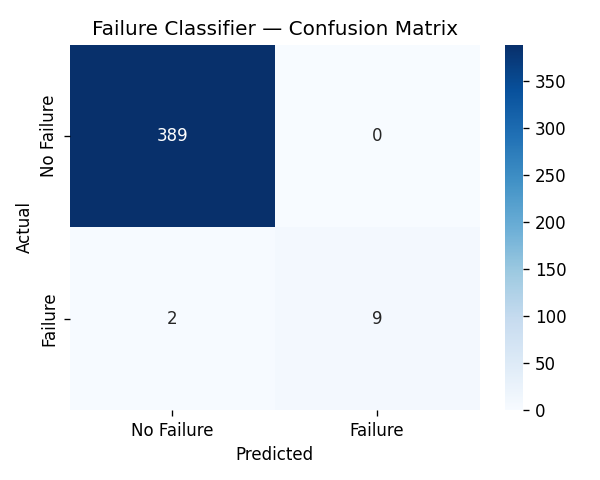

In [26]:
from IPython.display import Image
Image("/content/vehicle_health_engine/outputs/confusion_matrix.png")

In [27]:
import sys
sys.path.insert(0, "/content/vehicle_health_engine")

import joblib, pandas as pd
from src.feature_engineering import engineer_features
from src.health_scoring import add_all_health_scores
from src.train_classifier import get_feature_columns, add_ml_health_score

# Load saved model
clf = joblib.load("/content/vehicle_health_engine/models/failure_classifier.joblib")

# Your sensor reading
reading = {
    "temperature":     95.0,
    "pressure":        28.0,
    "rpm":             3200.0,
    "vibration":       0.5,
    "battery_voltage": 12.1,
    "battery_current": 60.0,
    "battery_temp":    42.0,
    "fault_count":     2.0,
    "failure":         0,
}

df = pd.DataFrame([reading])
df = engineer_features(df)
df = add_all_health_scores(df)
df = add_ml_health_score(df, clf)

result = df[["engine_health","battery_health","vehicle_health",
             "ml_health_score","trip_readiness","trip_readiness_label",
             "health_class","health_class_id"]].iloc[0]

print("━" * 40)
print("  VEHICLE HEALTH PREDICTION")
print("━" * 40)
for k, v in result.items():
    print(f"  {k:<25} {v}")
print("━" * 40)

07:34:56 | INFO     | src.feature_engineering | Feature engineering complete.


INFO:src.feature_engineering:Feature engineering complete.


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  VEHICLE HEALTH PREDICTION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  engine_health             76.66666666666667
  battery_health            79.37499999999997
  vehicle_health            77.47916666666666
  ml_health_score           21.666563034057617
  trip_readiness            78.36249999999998
  trip_readiness_label      Ready
  health_class              Good
  health_class_id           1
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


In [28]:
import shutil
from google.colab import files

# Zip everything and download
shutil.make_archive("/content/vehicle_health_outputs", "zip",
                    "/content/vehicle_health_engine/outputs")
files.download("/content/vehicle_health_outputs.zip")

# Or download the dataset CSV directly
files.download("/content/vehicle_health_engine/outputs/vehicle_health_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>